In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

## This script implements an entropy-based model for detecting attacks in CAN bus data.
## Data used for training: benign Car Hacking Dataset
## Data used for testing: Adversarial_traffic_Both_transformed.csv

In [12]:
class EntropyModel:

    def __init__(self, benign_data_path, attack_data_path = False):
        self.benign_df = self.load_data(benign_data_path)
        self.benign_df = self.transform_data(self.benign_df)
        self.benign_df['label'] = 0  # Add a label column for benign data
        self.train_data = self.benign_df[0:int(0.2*len(self.benign_df))]
        self.val_data = self.benign_df[int(0.2*len(self.benign_df)):]
        if attack_data_path:
            self.attack_data = self.load_test_data(attack_data_path)
            
        # print("Splitting into Windows!")
        # self.windows, self.window_labels, _ = self.split_into_windows(self.train_data, 1)
        # print("Calculating Entropy and stats!")
        # self.entropies = self.calculate_entropy(self.windows)
        # self.entropy_stats = self.calculate_stats(self.benign_df)


    
    def load_data(self, file_path):
        # Read the file line by line
        
        # Create a dataframe
        df = pd.read_csv(file_path)
        # Convert Timestamp to float
        df['Timestamp'] = df['Timestamp'].astype(float)

        return df
    
    def load_test_data(self, file_path):

        attack_df = pd.read_csv(file_path)
        # print(attack_df.head())
        # print(attack_df.columns)
        attack_df = self.transform_data(attack_df)
        attack_df['label'] = attack_df['label'].astype(int)  # Ensure label is integer type
        
        return attack_df
        
    def hex_to_dec(self, x):
        return int(str(x), 16)

    def transform_data(self, data):

        data['ID'] = data['ID'].apply(self.hex_to_dec)
        data['Payload'] = data['Payload'].apply(self.hex_to_dec)

        return data
    
    def split_into_windows(self, df, window_size):

        # print(df.head())
        # print(df.tail())
   
        start_time = df['Timestamp'].min()
        end_time = df['Timestamp'].max()
        
        windows = []
        window_labels = []  # To store the label for each window
        current_time = start_time
        
        while current_time <= end_time:
            # Extract data for the current window
            window = df[(df['Timestamp'] >= current_time) & 
                        (df['Timestamp'] < current_time + window_size)]
            
            try:
                window_label = window['label']
            except:
                print("No label column found in the window, skipping this window.")
                print(window)
                window_label = pd.Series([0] * len(window))

            if not window.empty:
                windows.append(window)
                
                # Assign window label: 1 if any label is 1 in the window, else 0
                if (window['label'] == 1).any():
                    window_labels.append(1)
                else:
                    window_labels.append(0)
            
            # Move to next window
            current_time += window_size
    
        return windows, window_labels, len(windows)

    def calculate_entropy(self, windows):
        """
        Calculate entropy for each window.
        
        Args:
            windows (list): List of windowed dataframes.
            
        Returns:
            list: List of entropy values for each window.
        """
        entropies = []
        
        for window in windows:
            # Count unique combinations of Identifier, Data Length Code, and Data
            counts = window.groupby(['ID', 'DLC', 'Payload']).size()
            total = counts.sum()
            
            if total > 0:
                # Compute probability
                probabilities = counts / total
                
                # Calculate entropy using the definition
                entropy = -np.sum(probabilities * np.log2(probabilities))
                entropies.append(entropy)
        
        return entropies
    
    def detect_attack(self, entropy, threshold):
        """
        Detects attack based on entropy values and threshold.
        
        Args:
            entropy (list): Entropy list.
            threshold (list): Lower and upper threshold values.
            
        Returns:
            predicted_labels (list): List of predicted labels (1 if attack, else 0).
        """
        predicted_labels = []
        
        for e in entropy:
            if e < threshold[0] or e > threshold[1]:
                predicted_labels.append(1)
            else:
                predicted_labels.append(0)
        
        return predicted_labels
    
    def calculate_stats(self, benign_data):
        entropy_dict = {}  # Dictionary to store entropy values by window size
        window_labels_dict = {}  # Stores window labels by window size

        window_sizes = [1, 0.5, 0.1, 0.032768]  # in seconds
        for window_size in window_sizes:
            windows, window_labels, num_windows = self.split_into_windows(benign_data, window_size)
            entropies = self.calculate_entropy(windows)
            
            # Store entropy values in dictionary
            entropy_dict[window_size] = entropies
            window_labels_dict[window_size] = window_labels

        train_window_032768 = entropy_dict[0.032768]  # 32.768 ms window
        train_window_01 = entropy_dict[0.1]
        train_window_05 = entropy_dict[0.5]
        train_window_1 = entropy_dict[1]

        train_entropy_1_mean, train_entropy_1_std = np.mean(train_window_1), np.std(train_window_1)
        train_entropy_05_mean, train_entropy_05_std = np.mean(train_window_05), np.std(train_window_05)
        train_entropy_01_mean, train_entropy_01_std = np.mean(train_window_01), np.std(train_window_01)
        train_entropy_032768_mean, train_entropy_032768_std = np.mean(train_window_032768), np.std(train_window_032768)

        return (train_entropy_1_mean, train_entropy_1_std), (train_entropy_05_mean, train_entropy_05_std), (train_entropy_01_mean, train_entropy_01_std), (train_entropy_032768_mean, train_entropy_032768_std)


    # def find_threshold(self):
    #     thresholds = {}
    #     k_values = {}
    #     window_sizes = [1, 0.5, 0.1, 0.032768]

    #     for window_size in window_sizes:
    #         # Calculate stats for current window size on train_data
    #         stats = self.calculate_stats(self.train_data)
    #         if window_size == 1:
    #             mean, std = stats[0]
    #         elif window_size == 0.5:
    #             mean, std = stats[1]
    #         elif window_size == 0.1:
    #             mean, std = stats[2]
    #         elif window_size == 0.032768:
    #             mean, std = stats[3]

    #         # Split validation data into windows for this size
    #         val_windows, val_window_labels, _ = self.split_into_windows(self.val_data, window_size)
    #         val_entropies = self.calculate_entropy(val_windows)


    #         k_list = [0.1, 0.5, 1, 2, 3, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100]


    #         for k_val in k_list:
    #             threshold = [mean - k_val * std, mean + k_val * std]
    #             predictions = self.detect_attack(val_entropies, threshold)

    #             ##calculate Accuracy, Precisionm, Recall, F1-Score
    #             accuracy = 

        #     k = 1
        #     # k_list = [0.1, 0.5, 1, 2, 3, 5, 10, 15]
        #     flag = False

        #     while not flag:
        #         threshold = [mean - k * std, mean + k * std]
        #         predictions = self.detect_attack(val_entropies, threshold)

        #         false_positives = sum(predictions)  # since all benign validation windows should be 0

        #         if false_positives == 0:
        #             flag = True  # stop when no false positives
        #             thresholds[window_size] = threshold
        #             k_values[window_size] = k
        #         else:
        #             k += 1  # increment k and try again

        # return thresholds, k_values
    
    def evaluate_model(self, window_size = 0.032768):

        test_data = self.attack_data

        # print(test_data.columns)

        # data = test_data[['Timestamp', 'ID', 'DLC', 'Payload']]  # Exclude the label column
        data = test_data
        labels = test_data[['label']]  # Keep the label column for evaluation 
        windows, window_labels, no_windows = self.split_into_windows(pd.DataFrame(data), window_size)
        entropies = self.calculate_entropy(windows)

        k_list = [0.1, 0.5, 1, 2, 3, 5]
        thresholds = {}
        k_vals = {}
        
        for k_val in k_list:
            thresholds[k_val] = [np.mean(entropies) - k_val * np.std(entropies), np.mean(entropies) + k_val * np.std(entropies)]
            k_vals[k_val] = k_val

        ##Plot on y-axis (Acccuracy, Precision, Recall, F1-Score) and on x-axis (k value) log scale
        accuracies = []
        precisions = []
        recalls = []
        f1_scores = []
        for k_val in k_list:
            threshold = thresholds[k_val]
            predictions = self.detect_attack(entropies, threshold)
            accuracy = accuracy_score(window_labels, predictions)
            precision = precision_score(window_labels, predictions, zero_division=0)
            recall = recall_score(window_labels, predictions, zero_division=0)
            f1 = f1_score(window_labels, predictions, zero_division=0)

            accuracies.append(accuracy)
            precisions.append(precision)
            recalls.append(recall)
            f1_scores.append(f1)

        ##Plot the resuts on log scale

        plt.figure(figsize=(12, 8))
        plt.plot(k_list, accuracies, marker='o', label='Accuracy')
        plt.plot(k_list, precisions, marker='o', label='Precision')
        plt.plot(k_list, recalls, marker='o', label='Recall')
        plt.plot(k_list, f1_scores, marker='o', label='F1-Score')
        plt.xlabel('k Value')
        plt.ylabel('Score')
        plt.title('Model Performance vs k Value')
        plt.xticks(k_list)
        plt.legend()
        # plt.grid()
        plt.show()
        


        # thresholds, k_vals = self.find_threshold()
        
        # threshold = thresholds[window_size]
        # k = k_vals[window_size]

        # predictions = self.detect_attack(entropies, threshold)
        # accuracy = accuracy_score(window_labels, predictions)
        
        # print(f"Threshold range: {threshold}")
        # print(f"k value used: {k}")
        # print(f"Accuracy: {accuracy * 100:.2f}%")
        # print("Classification Report:")
        # print(classification_report(window_labels, predictions))
        # print("Confusion Matrix:")
        # cm = confusion_matrix(window_labels, predictions)
        # plt.figure(figsize=(8, 6))
        # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
        # plt.xlabel('Predicted')
        # plt.ylabel('Actual')
        # plt.title('Confusion Matrix')
        # plt.show()

Evaluating model!


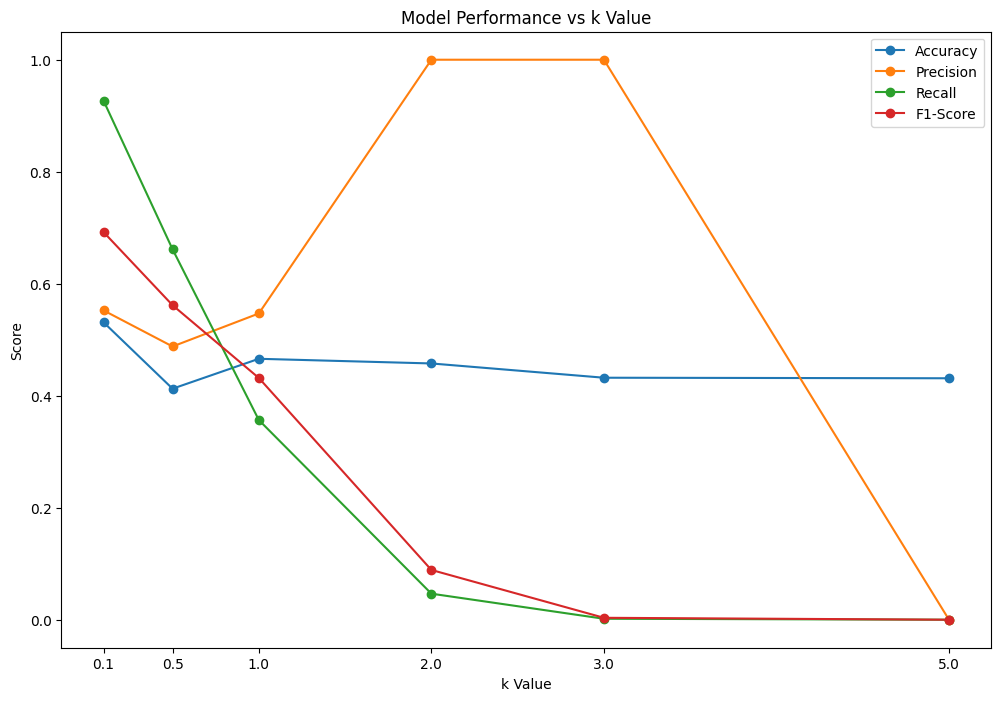

In [13]:
##Take Car Hacking benign data and attack data
data_path = '../../Smart attack Algorithm/data/Car Hacking Dataset/'
##Enter benign data path
benign_data_path = os.path.join(data_path, 'benign_data.csv')

##Enter perturbed traffic path
attack_data_path = 'Adversarial_traffic_Both_transformed.csv'

##Create entropy model instance
car_hacking_entropy = EntropyModel(benign_data_path, attack_data_path)
print("Evaluating model!")

##Evaluate the model
car_hacking_entropy.evaluate_model()
